In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("loan.csv")
df.head()

,applicant_id,gender,age,income,loan_amount,credit_score,employment_status,marital_status,loan_approved
0,1,Male,52,65993,10104,522,Unemployed,Married,0
1,2,Female,59,44592,39911,552,Unemployed,Single,0
2,3,Male,52,25647,28190,664,Employed,Single,1
3,4,Male,24,23716,12357,701,Unemployed,Married,0
4,5,Male,50,103891,37479,582,Unemployed,Married,0


In [4]:
df.shape

(200, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   applicant_id       200 non-null    int64 
 1   gender             200 non-null    object
 2   age                200 non-null    int64 
 3   income             200 non-null    int64 
 4   loan_amount        200 non-null    int64 
 5   credit_score       200 non-null    int64 
 6   employment_status  200 non-null    object
 7   marital_status     200 non-null    object
 8   loan_approved      200 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 14.2+ KB


In [6]:
print(df.isnull().sum())

applicant_id         0
gender               0
age                  0
income               0
loan_amount          0
credit_score         0
employment_status    0
marital_status       0
loan_approved        0
dtype: int64


In [7]:
print(df.describe())

       applicant_id        age         income   loan_amount  credit_score  \
count    200.000000  200.00000     200.000000    200.000000    200.000000   
mean     100.500000   41.79500   71384.345000  28042.725000    669.195000   
std       57.879185   11.72306   31437.816323  12922.229297    105.718584   
min        1.000000   21.00000   15412.000000   5009.000000    500.000000   
25%       50.750000   31.00000   43104.000000  16430.500000    573.500000   
50%      100.500000   44.00000   74188.000000  28600.500000    670.500000   
75%      150.250000   52.00000  101188.250000  39692.750000    756.500000   
max      200.000000   59.00000  119185.000000  49912.000000    849.000000   

       loan_approved  
count     200.000000  
mean        0.550000  
std         0.498742  
min         0.000000  
25%         0.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  


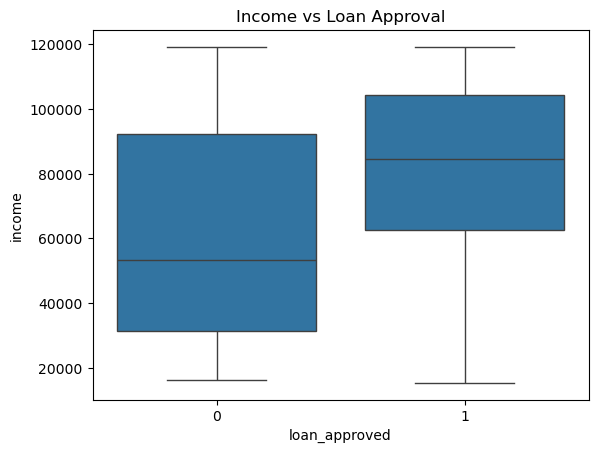

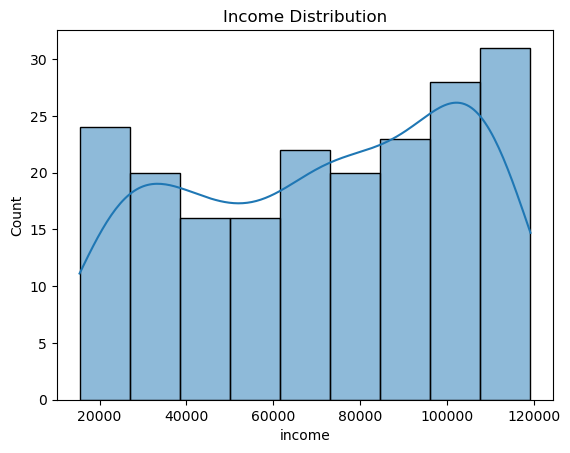

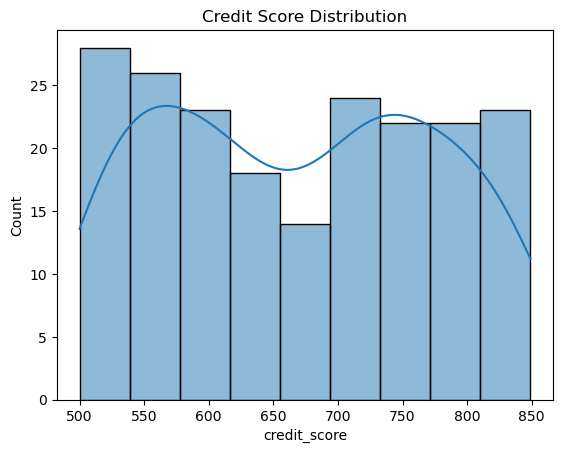

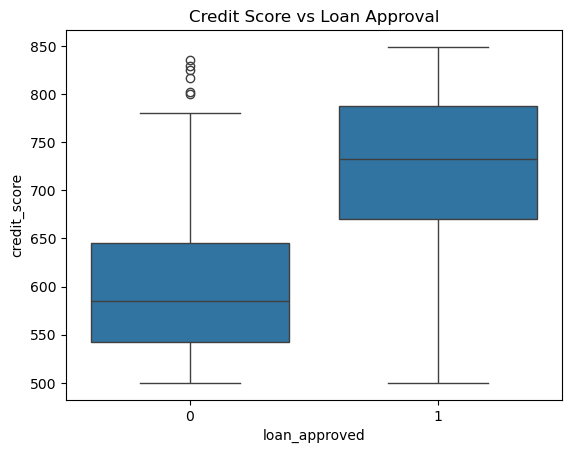

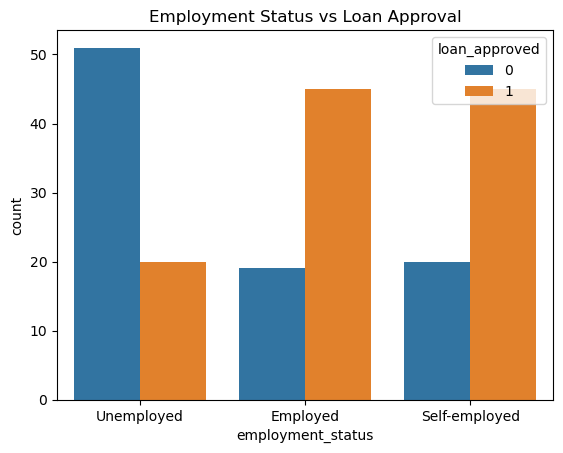

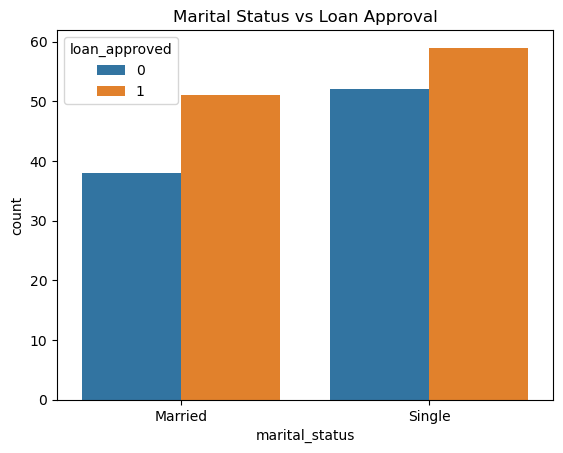

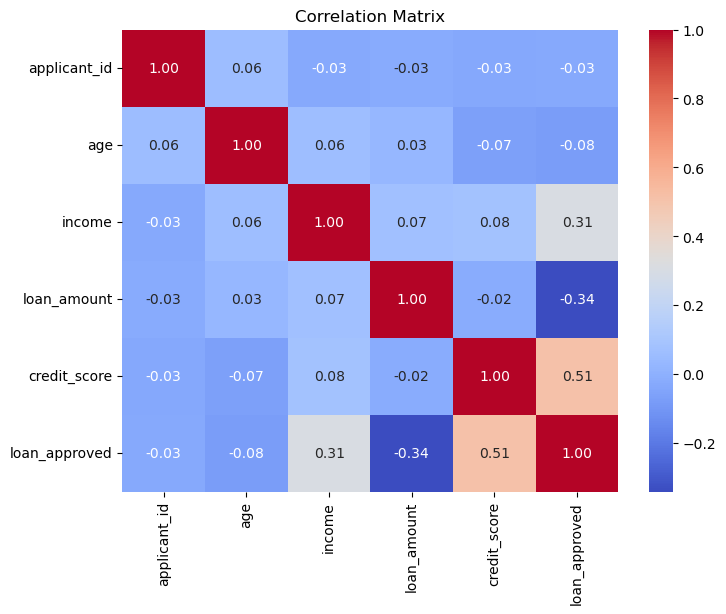

loan_approved    1.000000
credit_score     0.511940
income           0.306770
applicant_id    -0.026982
age             -0.075161
loan_amount     -0.340756
Name: loan_approved, dtype: float64


In [8]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title("Income vs Loan Approval")
plt.show()

sns.histplot(df['income'], kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(df['credit_score'], kde=True)
plt.title("Credit Score Distribution")
plt.show()

sns.boxplot(x='loan_approved', y='credit_score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

sns.countplot(x='employment_status', hue='loan_approved', data=df)
plt.title("Employment Status vs Loan Approval")
plt.show()

sns.countplot(x='marital_status', hue='loan_approved', data=df)
plt.title("Marital Status vs Loan Approval")
plt.show()

num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

corr_target = corr['loan_approved'].sort_values(ascending=False)
print(corr_target)

In [9]:

df["income_loan_ratio"] = df["income"] / (df["loan_amount"] + 1)


df["loan_burden"] = df["loan_amount"] / (df["income"] + 1)


df["age_group"] = pd.cut(df["age"], bins=[18,30,45,60,100], labels=[0,1,2,3])


df["income_level"] = pd.qcut(df["income"], 4, labels=[0,1,2,3])


df["loan_level"] = pd.qcut(df["loan_amount"], 4, labels=[0,1,2,3])


df["risk_score"] = (
    df["loan_amount"] * 0.6 -
    df["income"] * 0.3 +
    df["age"] * 0.1
)
df["income_x_age"] = df["income"] * df["age"]
df["loan_x_income"] = df["loan_amount"] * df["income"]
df["loan_per_age"] = df["loan_amount"] / (df["age"] + 1)
df["loan_amount_log"] = np.log1p(df["loan_amount"])
df["income_log"] = np.log1p(df["income"])


In [10]:
X = df.drop("loan_approved", axis = 1)
Y = df["loan_approved"]

num_cols = X.select_dtypes(include=["int64", "float64","datetime"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

num_transformer = StandardScaler()  
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ("Num", num_transformer, num_cols),
    ("Cat", cat_transformer, cat_cols)
])

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (160, 19)
Testing set shape: (40, 19)


In [12]:
pipe = Pipeline([
    ("Pre", preprocessor),
    ("DesT", DecisionTreeClassifier(random_state=42))
])

pipe.fit(X_train, Y_train)


,steps,"[('Pre', ...), ('DesT', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Num', ...), ('Cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
Y_pred = pipe.predict(X_test)
Y_pred_proba = pipe.predict_proba(X_test)[:,1]  
print(Y_pred)
print(Y_pred_proba)

[1 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0
 0 1 1]
[1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0.
 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1.]


In [14]:
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
roc_auc = roc_auc_score(Y_test,Y_pred_proba)

In [15]:
print("\nDecision Tree Results")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred))


Decision Tree Results
Accuracy : 0.85
Precision: 0.8636
Recall   : 0.8636
F1 Score : 0.8636
ROC-AUC  : 0.8485

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.86      0.86      0.86        22

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40


Confusion Matrix
[[15  3]
 [ 3 19]]


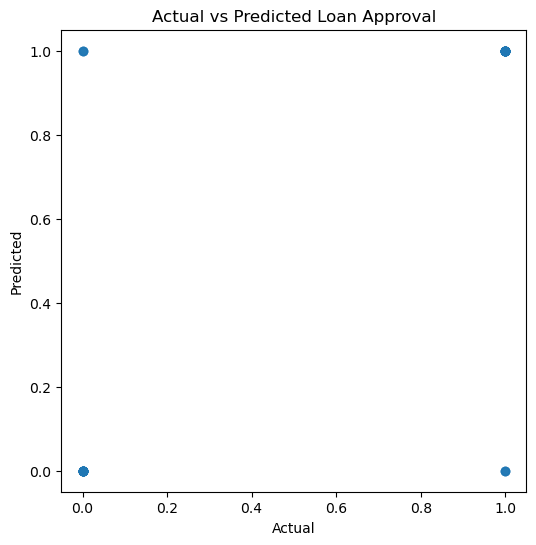

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Loan Approval")
plt.show()

Fold Scores: [0.96865764 0.87400794 0.96859359 0.8754902  0.90652709]
Average F1: 0.9186552910488002


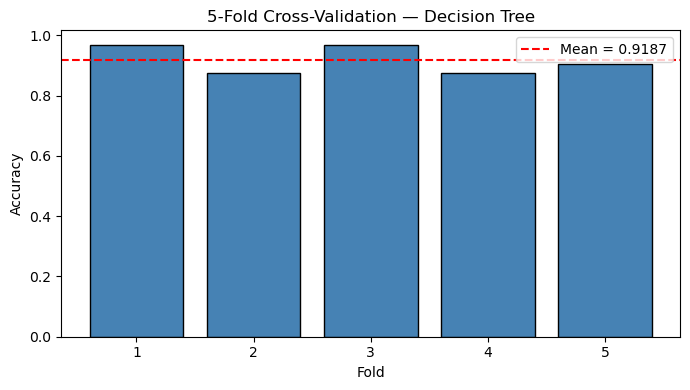

In [17]:
# Cross Validation 
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipe,
    X_train,
    Y_train,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1
)

print("Fold Scores:", cv_scores)
print("Average F1:", cv_scores.mean())

# Visualise the fold scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold'); plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation — Decision Tree')
plt.legend(); plt.tight_layout(); plt.show()

In [18]:
# ── GridSearchCV on Dt pipeline 
Dt_param_grid = {
    'DesT__max_depth': [5, 10, 15, None],
    'DesT__min_samples_split': [2, 5, 10],
    'DesT__min_samples_leaf': [1, 2, 4],
    'DesT__criterion': ['gini', 'entropy']
}

grid_search_Dt = GridSearchCV(
    estimator=Pipeline([
        ("Pre", preprocessor),
        ("DesT", DecisionTreeClassifier(random_state=42))
    ]),
    param_grid=Dt_param_grid,
    cv=skf,          
    scoring='f1',
    n_jobs=-1,               
    
)

grid_search_Dt.fit(X_train, Y_train)

print("Tuned Dt parameters :", grid_search_Dt.best_params_)
print(f"Tuned CV accuracy    : {grid_search_Dt.best_score_:.4f}")
Tuned_dt = grid_search_Dt.best_estimator_

Tuned Dt parameters : {'DesT__criterion': 'entropy', 'DesT__max_depth': 5, 'DesT__min_samples_leaf': 1, 'DesT__min_samples_split': 2}
Tuned CV accuracy    : 0.9552


In [19]:
# Evaluate the tuned Dt on the held-out test set
Y_pred_tuned = Tuned_dt.predict(X_test)
Y_pred_proba_tuned = Tuned_dt.predict_proba(X_test)[:,1]  
print(Y_pred_tuned )
print(Y_pred_proba_tuned)

[1 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0
 0 1 1]
[1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0.
 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1.]


In [20]:
accuracy = accuracy_score(Y_test, Y_pred_tuned)
precision = precision_score(Y_test, Y_pred_tuned)
recall = recall_score(Y_test, Y_pred_tuned)
f1 = f1_score(Y_test, Y_pred_tuned)
roc_auc = roc_auc_score(Y_test,Y_pred_proba_tuned)

In [21]:
print("\n Tuned Decision Tree Results")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred_tuned))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred_tuned))


 Tuned Decision Tree Results
Accuracy : 0.85
Precision: 0.8636
Recall   : 0.8636
F1 Score : 0.8636
ROC-AUC  : 0.8485

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.86      0.86      0.86        22

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40


Confusion Matrix
[[15  3]
 [ 3 19]]


In [22]:
# ── Random Forest with GridSearchCV 
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'RF__n_estimators': [100, 200, 300],
    'RF__max_depth': [5, 10, 15, None],
    'RF__min_samples_split': [2, 5, 10],
    'RF__min_samples_leaf': [1, 2, 4]
}

rf_pipe = Pipeline([
    ("Pre", preprocessor),
    ("RF", RandomForestClassifier(random_state=42))
])

grid_search_rf = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_rf.fit(X_train, Y_train)

print("Tuned RF parameters :", grid_search_rf.best_params_)
print(f"Tuned CV accuracy   : {grid_search_rf.best_score_:.4f}")

Tuned_rf = grid_search_rf.best_estimator_

Tuned RF parameters : {'RF__max_depth': 5, 'RF__min_samples_leaf': 1, 'RF__min_samples_split': 2, 'RF__n_estimators': 300}
Tuned CV accuracy   : 0.8653


In [23]:
# Evaluate the tuned RF on the held-out test set
Y_pred_tuned_rf = Tuned_rf.predict(X_test)
Y_pred_proba_tuned_rf = Tuned_rf.predict_proba(X_test)[:,1]  
print(Y_pred_tuned_rf )
print(Y_pred_proba_tuned_rf)

[1 1 1 1 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0
 0 1 0]
[0.96983553 0.94612097 0.74045772 0.75622648 0.98355945 0.73016747
 0.08576354 0.65555949 0.11656082 0.06359392 0.28211734 0.73805341
 0.75509688 0.05021508 0.61199372 0.49315746 0.90010055 0.80440964
 0.41964244 0.70048339 0.73602288 0.55598697 0.94599516 0.21009328
 0.4232191  0.58692872 0.44730815 0.50055911 0.04764317 0.03875084
 0.21492281 0.62151725 0.94042484 0.0246746  0.42311015 0.16349286
 0.49705415 0.25822318 0.51927667 0.46168602]


In [24]:
accuracy = accuracy_score(Y_test, Y_pred_tuned_rf)
precision = precision_score(Y_test, Y_pred_tuned_rf)
recall = recall_score(Y_test, Y_pred_tuned_rf)
f1 = f1_score(Y_test, Y_pred_tuned_rf)
roc_auc = roc_auc_score(Y_test,Y_pred_proba_tuned_rf)

In [25]:
print("\n Tuned Random Forest Results")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred_tuned_rf))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred_tuned_rf))


 Tuned Random Forest Results
Accuracy : 0.725
Precision: 0.7619
Recall   : 0.7273
F1 Score : 0.7442
ROC-AUC  : 0.8864

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.72      0.70        18
           1       0.76      0.73      0.74        22

    accuracy                           0.72        40
   macro avg       0.72      0.72      0.72        40
weighted avg       0.73      0.72      0.73        40


Confusion Matrix
[[13  5]
 [ 6 16]]


In [26]:
# Collect all models and their predictions
models = {
    'Decision Tree': (pipe, Y_pred),
    'Tuned Decision Tree': (grid_search_Dt, Y_pred_tuned),
    'Tuned Random Forest': (grid_search_rf, Y_pred_tuned_rf),
    
}

results = []
for name, (model, preds) in models.items():
    # roc_auc needs probability scores
    try:
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(Y_test, proba)
    except Exception:
        auc = float('nan')
    results.append({
        'Model'   : name,
        'f1': f1_score(Y_test, Y_pred),
        'ROC-AUC' : auc
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.to_string(index=False))

              Model       f1  ROC-AUC
      Decision Tree 0.863636 0.848485
Tuned Decision Tree 0.863636 0.848485
Tuned Random Forest 0.863636 0.886364


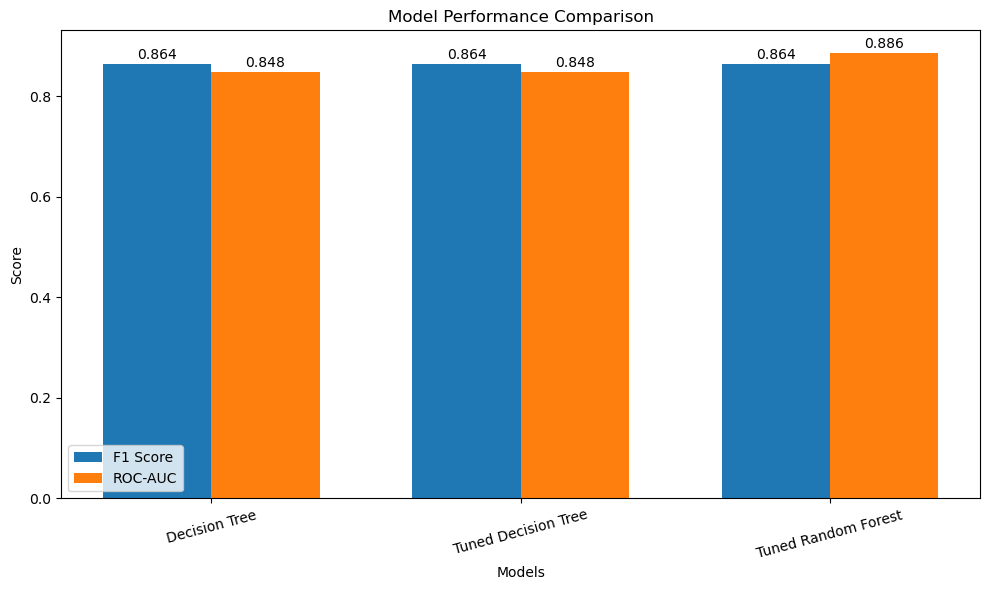

In [27]:
# Create figure
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(results_df))
width = 0.35

ax.bar(
    x - width/2,
    results_df['f1'],
    width,
    label='F1 Score'
)

ax.bar(
    x + width/2,
    results_df['ROC-AUC'],
    width,
    label='ROC-AUC'
)

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.legend()

# Add values on top
for i, v in enumerate(results_df['f1']):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center')

for i, v in enumerate(results_df['ROC-AUC']):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

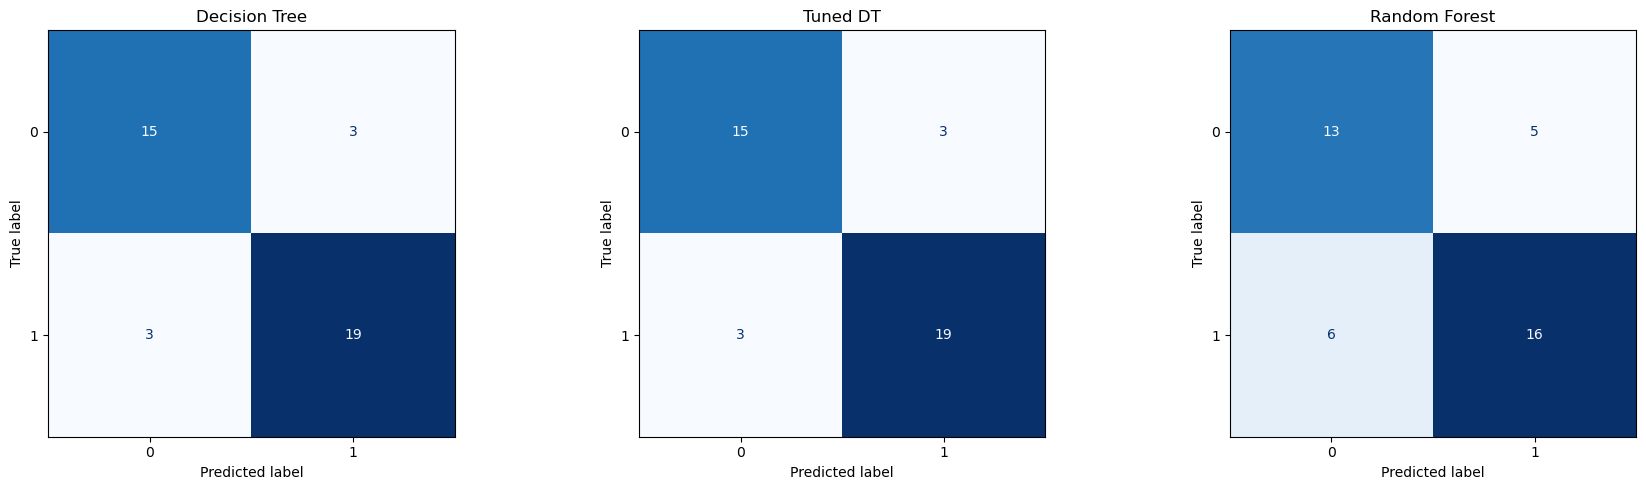

In [28]:
# Confusion matrices for all models

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = {
    "Decision Tree": pipe,
    "Tuned DT": grid_search_Dt,
    "Random Forest": grid_search_rf
}

for ax, (name, model) in zip(axes, models.items()):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        Y_test,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

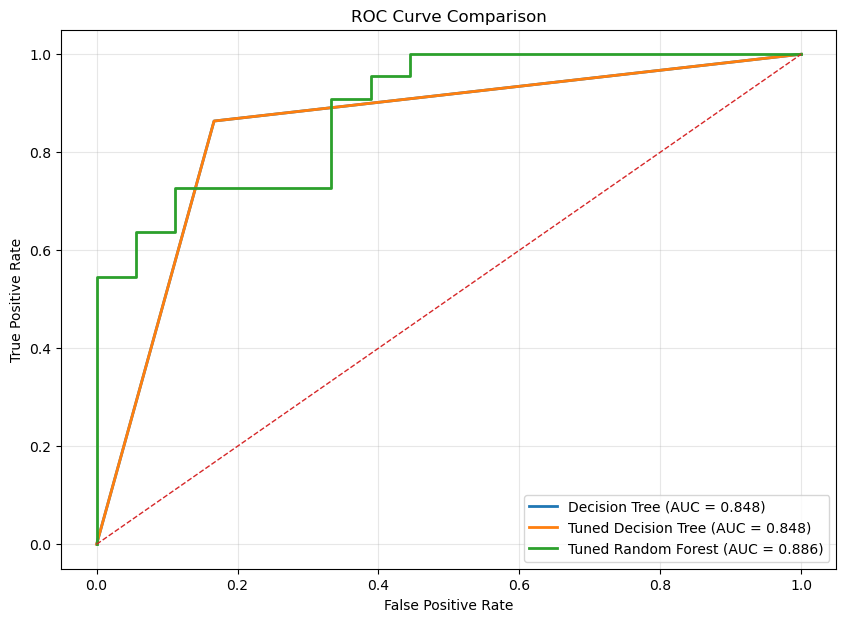

In [30]:
# ROC curves
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
dt_probs = pipe.predict_proba(X_test)[:, 1]
tuned_dt_probs = grid_search_Dt.predict_proba(X_test)[:, 1]
rf_probs = grid_search_rf.predict_proba(X_test)[:, 1]

# ROC values
dt_fpr, dt_tpr, _ = roc_curve(Y_test, dt_probs)
tuned_dt_fpr, tuned_dt_tpr, _ = roc_curve(Y_test, tuned_dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_probs)

# AUC Scores
dt_auc = roc_auc_score(Y_test, dt_probs)
tuned_dt_auc = roc_auc_score(Y_test, tuned_dt_probs)
rf_auc = roc_auc_score(Y_test, rf_probs)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=2,
    label=f'Decision Tree (AUC = {dt_auc:.3f})'
)

plt.plot(
    tuned_dt_fpr,
    tuned_dt_tpr,
    linewidth=2,
    label=f'Tuned Decision Tree (AUC = {tuned_dt_auc:.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Tuned Random Forest (AUC = {rf_auc:.3f})'
)

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [31]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj  = models[best_model_name][0]

In [32]:
import joblib
joblib.dump(best_model_obj, 'best_model.pkl')
print(f" Best model '{best_model_name}' saved to best_model.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")
print( "saved columns successfully")

 Best model 'Decision Tree' saved to best_model.pkl
saved columns successfully
